# Travel Style Classification — Clean sklearn Workflow

This notebook applies the requested classroom-style workflow to:

- **Target column:** `Travel Style`
- **Problem type:** multiclass classification
- **ID / non-predictive column:** `Destination Name`
- **Leakage columns:** none after separating the target

The main metric is **macro F1**, because the classes are not perfectly balanced.

## 1. Import required libraries

In [93]:
from __future__ import annotations

import json
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATASET_PATH = Path("/content/travel_data.csv")
TARGET_COLUMN = "Travel Style"
ID_COLUMNS = ["Destination Name"]
LEAKAGE_COLUMNS = []
PRIMARY_METRIC = "f1_macro"

OUTPUT_DIR = Path("../outputs")
MODEL_DIR = Path("../models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

## 2. Load the dataset and inspect

We inspect shape, column names, dtypes, missing values, duplicates, target distribution, and suspicious columns.

In [64]:
df = pd.read_csv(DATASET_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts())

df.head()

Shape: (200, 10)

Columns:
['Destination Name', 'Country', 'Continent', 'Type', 'Avg Cost (USD/day)', 'Best Season', 'Avg Rating', 'Annual Visitors (M)', 'UNESCO Site', 'Travel Style']

Dtypes:
Destination Name        object
Country                 object
Continent               object
Type                    object
Avg Cost (USD/day)     float64
Best Season             object
Avg Rating             float64
Annual Visitors (M)    float64
UNESCO Site             object
Travel Style            object
dtype: object

Missing values:
Destination Name       0
Country                0
Continent              0
Type                   0
Avg Cost (USD/day)     0
Best Season            0
Avg Rating             0
Annual Visitors (M)    0
UNESCO Site            0
Travel Style           0
dtype: int64

Duplicate rows: 0

Target distribution:
Travel Style
Family        43
Culture       39
Luxury        38
Budget        37
Adventure     23
Relaxation    20
Name: count, dtype: int64


,Destination Name,Country,Continent,Type,Avg Cost (USD/day),Best Season,Avg Rating,Annual Visitors (M),UNESCO Site,Travel Style
0,Hidden Forest,China,Asia,Nature,211.23,Autumn,5.0,5.69,No,Luxury
1,Lush Canyon,Egypt,Africa,City,219.79,Summer,4.1,5.92,No,Luxury
2,Mystic Pagoda,Kenya,Africa,Nature,123.12,Autumn,4.7,6.70,No,Family
3,Crystal Falls,Spain,Europe,Historical,162.47,Autumn,4.8,6.02,Yes,Culture
4,Golden Park,Greece,Europe,Nature,179.34,Winter,5.0,1.36,No,Family


### Suspicious columns

- `Destination Name` is removed because it behaves like an identifier and could lead to memorisation.
- `Travel Style` is the target, so it must never be included in `X`.
- No additional leakage columns are present in the 200-row dataset.

## 3. Clean the dataset

Cleaning rules used here:

1. Strip whitespace from text columns.
2. Drop duplicate rows.
3. Convert numeric-looking object columns safely.
4. Remove pure ID/non-predictive columns.
5. Keep the target separate from the features.

In [65]:
def safe_convert_numeric_objects(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """Convert object columns to numeric only when most values are numeric-looking."""
    df = df.copy()
    for col in df.columns:
        if col == target_col:
            continue
        if df[col].dtype == "object":
            converted = pd.to_numeric(df[col], errors="coerce")
            non_null_original = df[col].notna().sum()
            non_null_converted = converted.notna().sum()
            if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.90:
                df[col] = converted
    return df


df_clean = df.copy()

for col in df_clean.select_dtypes(include=["object", "category"]).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

before_duplicates = len(df_clean)
df_clean = df_clean.drop_duplicates()
print("Dropped duplicate rows:", before_duplicates - len(df_clean))

df_clean = safe_convert_numeric_objects(df_clean, TARGET_COLUMN)

columns_to_drop = [c for c in ID_COLUMNS + LEAKAGE_COLUMNS if c in df_clean.columns]
print("Columns to remove from features:", columns_to_drop)

df_clean.head()

Dropped duplicate rows: 0
Columns to remove from features: ['Destination Name']


,Destination Name,Country,Continent,Type,Avg Cost (USD/day),Best Season,Avg Rating,Annual Visitors (M),UNESCO Site,Travel Style
0,Hidden Forest,China,Asia,Nature,211.23,Autumn,5.0,5.69,No,Luxury
1,Lush Canyon,Egypt,Africa,City,219.79,Summer,4.1,5.92,No,Luxury
2,Mystic Pagoda,Kenya,Africa,Nature,123.12,Autumn,4.7,6.70,No,Family
3,Crystal Falls,Spain,Europe,Historical,162.47,Autumn,4.8,6.02,Yes,Culture
4,Golden Park,Greece,Europe,Nature,179.34,Winter,5.0,1.36,No,Family


## 4. Encode the target

This is a multiclass classification task. We can keep the target labels as strings because sklearn classifiers can handle string class labels directly.

We still print class counts and percentages to document imbalance.

In [66]:
y_full = df_clean[TARGET_COLUMN]

class_counts = y_full.value_counts().sort_index()
class_percentages = (class_counts / len(y_full) * 100).round(2)

target_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages
})

target_distribution

,count,percentage
Travel Style,,
Adventure,23,11.5
Budget,37,18.5
Culture,39,19.5
Family,43,21.5
Luxury,38,19.0
Relaxation,20,10.0


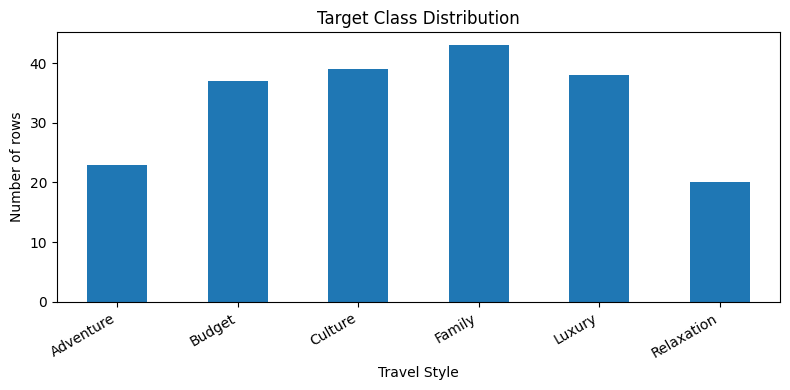

In [67]:
ax = target_distribution["count"].plot(kind="bar", figsize=(8, 4))
ax.set_title("Target Class Distribution")
ax.set_ylabel("Number of rows")
ax.set_xlabel("Travel Style")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Create `X` and `y`

In [68]:
X = df_clean.drop(columns=[TARGET_COLUMN] + columns_to_drop)
y = df_clean[TARGET_COLUMN]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

X shape: (200, 8)
y shape: (200,)

Feature columns:
['Country', 'Continent', 'Type', 'Avg Cost (USD/day)', 'Best Season', 'Avg Rating', 'Annual Visitors (M)', 'UNESCO Site']


## 6. Split the data

We use a stratified **60/20/20** split:

- 60% train
- 20% validation
- 20% test

The test set is not touched until the final evaluation.

In [69]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print("Train rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:", len(X_test))

Train rows: 120
Validation rows: 40
Test rows: 40


## 7. Verify the split

Stratification should keep class proportions similar across train, validation, and test.

In [70]:
def split_distribution(name: str, y_split: pd.Series) -> pd.DataFrame:
    counts = y_split.value_counts().sort_index()
    percentages = (counts / len(y_split) * 100).round(2)
    out = pd.DataFrame({"split": name, "count": counts, "percentage": percentages})
    return out

split_dist = pd.concat([
    split_distribution("train", y_train),
    split_distribution("validation", y_val),
    split_distribution("test", y_test),
])

split_dist

,split,count,percentage
Travel Style,,,
Adventure,train,14,11.67
Budget,train,22,18.33
Culture,train,23,19.17
Family,train,26,21.67
Luxury,train,23,19.17
Relaxation,train,12,10.00
Adventure,validation,4,10.00
Budget,validation,8,20.00
Culture,validation,8,20.00


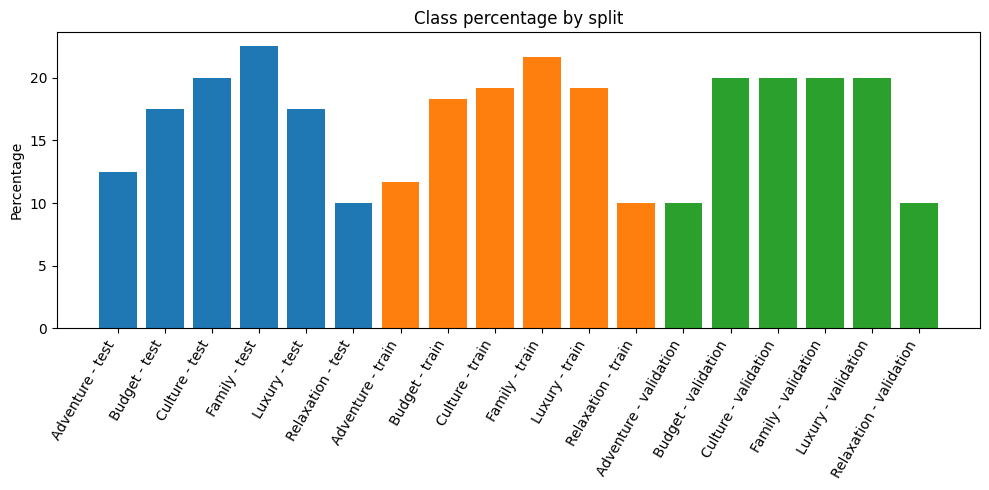

In [71]:
fig, ax = plt.subplots(figsize=(10, 5))
for split_name, group in split_dist.groupby("split"):
    ax.bar(
        group.index.astype(str) + " - " + split_name,
        group["percentage"],
        label=split_name,
    )

ax.set_title("Class percentage by split")
ax.set_ylabel("Percentage")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## 8. Identify feature types

We inspect dtypes instead of blindly hardcoding feature lists.

In [72]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train.dtypes

Numeric features: ['Avg Cost (USD/day)', 'Avg Rating', 'Annual Visitors (M)']
Categorical features: ['Country', 'Continent', 'Type', 'Best Season', 'UNESCO Site']


,0
Country,object
Continent,object
Type,object
Avg Cost (USD/day),float64
Best Season,object
Avg Rating,float64
Annual Visitors (M),float64
UNESCO Site,object


## 9. Build preprocessing inside a `ColumnTransformer`

Preprocessing is inside the pipeline to avoid leakage.

Numeric pipeline:

- median imputation
- standard scaling

Categorical pipeline:

- most frequent imputation
- one-hot encoding with unknown-category handling

In [73]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Avg Cost (USD/day)', 'Avg Rating',
                                  'Annual Visitors (M)']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Country', 'Continent', 'Type', 'Best Season',
                                  'UNESCO Site'])])

## 10. Build a baseline classifier pipeline

Baseline: Logistic Regression with `class_weight='balanced'`.

This keeps preprocessing and model training in one sklearn `Pipeline`.

In [74]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

baseline_pipeline.fit(X_train, y_train)
baseline_val_pred = baseline_pipeline.predict(X_val)

print("Baseline validation accuracy:", accuracy_score(y_val, baseline_val_pred))
print("Baseline validation macro F1:", f1_score(y_val, baseline_val_pred, average="macro", zero_division=0))

print("\nClassification report:")
print(classification_report(y_val, baseline_val_pred, zero_division=0))

Baseline validation accuracy: 0.675
Baseline validation macro F1: 0.6737950774715481

Classification report:
              precision    recall  f1-score   support

   Adventure       0.57      1.00      0.73         4
      Budget       1.00      0.62      0.77         8
     Culture       0.62      0.62      0.62         8
      Family       0.67      0.75      0.71         8
      Luxury       0.80      0.50      0.62         8
  Relaxation       0.50      0.75      0.60         4

    accuracy                           0.68        40
   macro avg       0.69      0.71      0.67        40
weighted avg       0.73      0.68      0.68        40



## 11. Create a reusable evaluation helper

In [75]:
def evaluate_model(
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    model_name: str,
) -> tuple[dict, Pipeline]:
    fitted = clone(pipeline)
    fitted.fit(X_train, y_train)

    train_pred = fitted.predict(X_train)
    val_pred = fitted.predict(X_val)

    train_accuracy = accuracy_score(y_train, train_pred)
    train_macro_f1 = f1_score(y_train, train_pred, average="macro", zero_division=0)

    val_accuracy = accuracy_score(y_val, val_pred)
    val_macro_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)
    val_precision_macro = precision_score(y_val, val_pred, average="macro", zero_division=0)
    val_recall_macro = recall_score(y_val, val_pred, average="macro", zero_division=0)

    result = {
        "model": model_name,
        "train_accuracy": train_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_accuracy": val_accuracy,
        "val_macro_f1": val_macro_f1,
        "val_precision_macro": val_precision_macro,
        "val_recall_macro": val_recall_macro,
        "train_val_accuracy_gap": train_accuracy - val_accuracy,
        "train_val_macro_f1_gap": train_macro_f1 - val_macro_f1,
    }

    return result, fitted

## 12. Train at least three classifiers

Each model gets its own pipeline with a cloned preprocessor.

In [94]:
models = {
    "LogisticRegression_balanced": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "classifier",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "RandomForest_balanced": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=100,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "ExtraTrees_balanced": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "classifier",
                ExtraTreesClassifier(
                    n_estimators=100,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "HistGradientBoosting_balanced": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "classifier",
                HistGradientBoostingClassifier(
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

validation_results = []
fitted_models = {}

for model_name, pipe in models.items():
    result, fitted = evaluate_model(pipe, X_train, y_train, X_val, y_val, model_name)
    validation_results.append(result)
    fitted_models[model_name] = fitted
    print(model_name, "validation macro F1:", round(result["val_macro_f1"], 4))

LogisticRegression_balanced validation macro F1: 0.6738
RandomForest_balanced validation macro F1: 0.7938
ExtraTrees_balanced validation macro F1: 0.6461
HistGradientBoosting_balanced validation macro F1: 0.5255


## 13. Compare models fairly

All models use the same train/validation split and the same preprocessing design.

Because classes are imbalanced, macro F1 is the primary comparison metric.

In [96]:
results_df = pd.DataFrame(validation_results).sort_values("val_macro_f1", ascending=False)
results_df

,model,train_accuracy,train_macro_f1,val_accuracy,val_macro_f1,val_precision_macro,val_recall_macro,train_val_accuracy_gap,train_val_macro_f1_gap
1,RandomForest_balanced,1.000000,1.000000,0.800,0.793838,0.798413,0.812500,0.200000,0.206162
0,LogisticRegression_balanced,0.983333,0.983121,0.675,0.673795,0.693849,0.708333,0.308333,0.309325
2,ExtraTrees_balanced,1.000000,1.000000,0.625,0.646083,0.663853,0.666667,0.375000,0.353917
3,HistGradientBoosting_balanced,1.000000,1.000000,0.550,0.525482,0.524074,0.541667,0.450000,0.474518


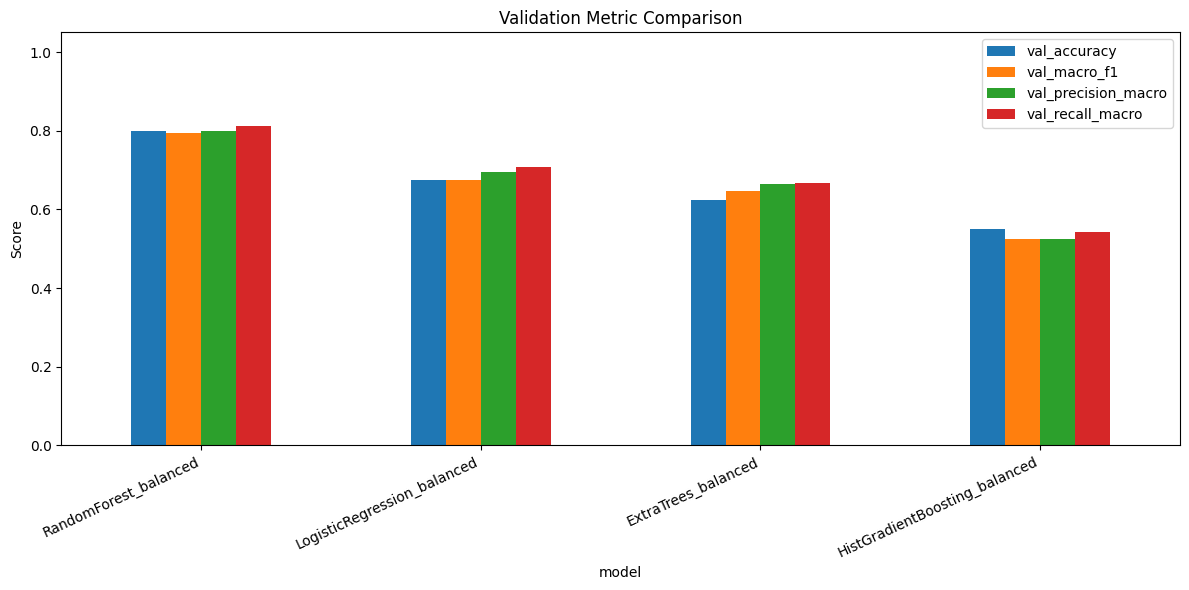

In [97]:
results_df.to_csv(OUTPUT_DIR / "results_validation.csv", index=False)
results_df.to_csv(OUTPUT_DIR / "results.csv", index=False)

metric_cols = [
    "val_accuracy",
    "val_macro_f1",
    "val_precision_macro",
    "val_recall_macro",
]

ax = results_df.set_index("model")[metric_cols].plot(kind="bar", figsize=(12, 6))
ax.set_title("Validation Metric Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 14. Run k-fold cross-validation

We use `StratifiedKFold` and do **not** preprocess outside the pipeline.

In [95]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
}

cv_rows = []

for model_name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=None,
    )

    row = {
        "model": model_name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_f1_std": scores["test_macro_f1"].std(),
        "cv_train_macro_f1_mean": scores["train_macro_f1"].mean(),
        "cv_train_val_macro_f1_gap": scores["train_macro_f1"].mean() - scores["test_macro_f1"].mean(),
    }
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).sort_values("cv_macro_f1_mean", ascending=False)
cv_df.to_csv(OUTPUT_DIR / "results_cv.csv", index=False)
cv_df

,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_train_macro_f1_mean,cv_train_val_macro_f1_gap
1,RandomForest_balanced,0.775000,0.089753,0.745663,0.117783,1.000000,0.254337
0,LogisticRegression_balanced,0.741667,0.084984,0.723284,0.098346,0.984110,0.260826
3,HistGradientBoosting_balanced,0.616667,0.031180,0.563064,0.063964,0.998147,0.435083
2,ExtraTrees_balanced,0.591667,0.084984,0.553918,0.105276,1.000000,0.446082


## 15. Analyse overfitting

A large train-validation gap suggests overfitting.

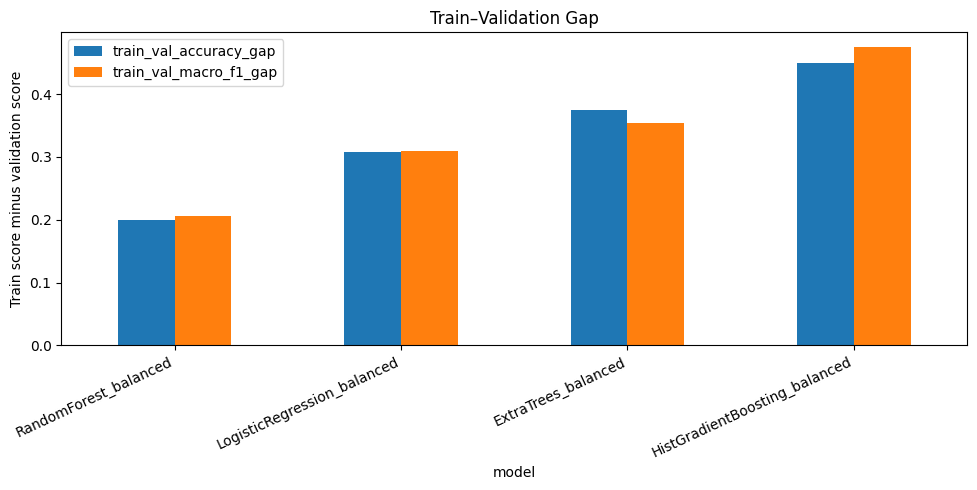

,model,train_macro_f1,val_macro_f1,train_val_macro_f1_gap
1,RandomForest_balanced,1.000000,0.793838,0.206162
0,LogisticRegression_balanced,0.983121,0.673795,0.309325
2,ExtraTrees_balanced,1.000000,0.646083,0.353917
3,HistGradientBoosting_balanced,1.000000,0.525482,0.474518


In [98]:
gap_cols = ["train_val_accuracy_gap", "train_val_macro_f1_gap"]

ax = results_df.set_index("model")[gap_cols].plot(kind="bar", figsize=(10, 5))
ax.set_title("Train–Validation Gap")
ax.set_ylabel("Train score minus validation score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

results_df[["model", "train_macro_f1", "val_macro_f1", "train_val_macro_f1_gap"]]

## 16. Handle class imbalance honestly

Actions taken:

- print class distribution
- use stratified splitting
- use macro F1, macro precision, macro recall
- use per-class reports
- use `class_weight='balanced'` where supported

SMOTE is not used because this workflow stays within sklearn only.

In [81]:
print("Full class distribution:")
display(target_distribution)

best_validation_model_name = results_df.iloc[0]["model"]
best_validation_model = fitted_models[best_validation_model_name]

val_pred_best = best_validation_model.predict(X_val)

print("Best validation model:", best_validation_model_name)
print("\nPer-class validation report:")
print(classification_report(y_val, val_pred_best, zero_division=0))

Full class distribution:


,count,percentage
Travel Style,,
Adventure,23,11.5
Budget,37,18.5
Culture,39,19.5
Family,43,21.5
Luxury,38,19.0
Relaxation,20,10.0


Best validation model: RandomForest_balanced

Per-class validation report:
              precision    recall  f1-score   support

   Adventure       0.67      1.00      0.80         4
      Budget       1.00      0.88      0.93         8
     Culture       0.86      0.75      0.80         8
      Family       0.67      0.75      0.71         8
      Luxury       1.00      0.75      0.86         8
  Relaxation       0.60      0.75      0.67         4

    accuracy                           0.80        40
   macro avg       0.80      0.81      0.79        40
weighted avg       0.83      0.80      0.81        40



## 17. Produce model comparison visuals

We already created the metric comparison and gap charts. Now we show confusion matrices.

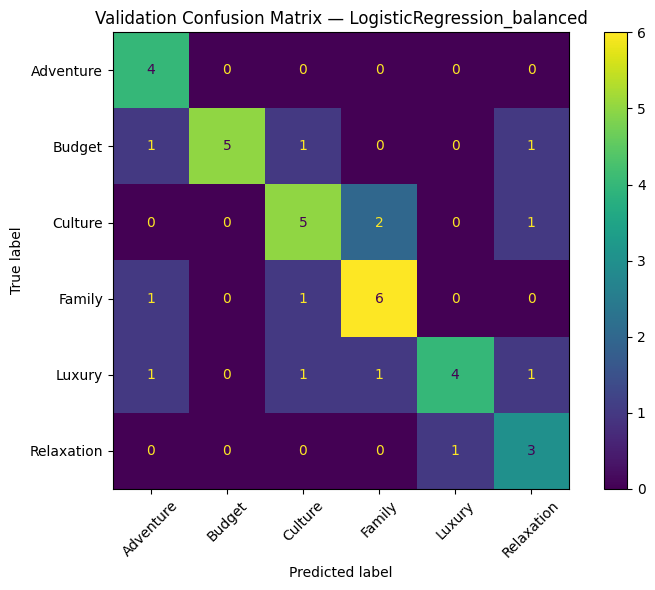

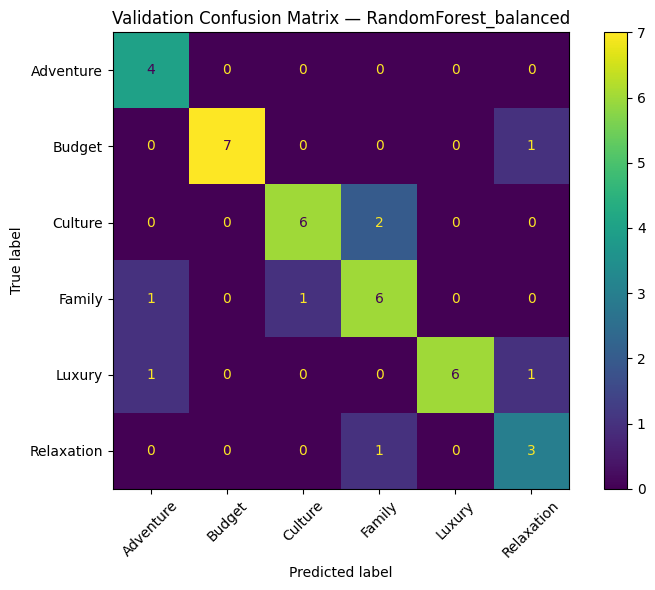

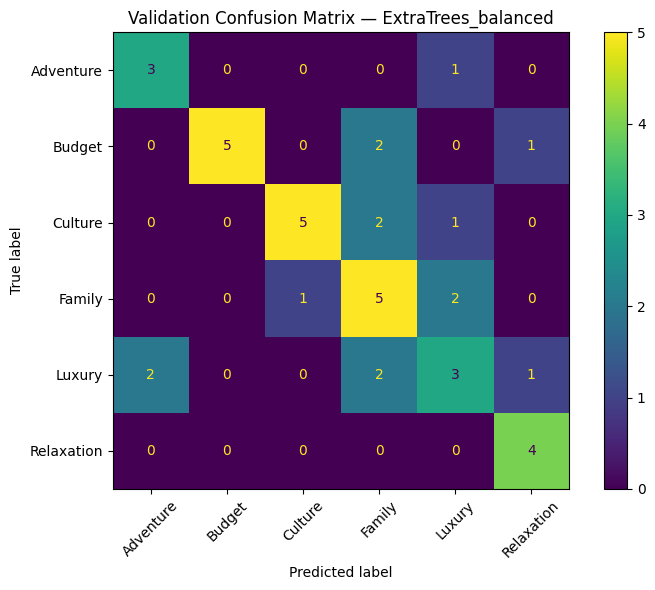

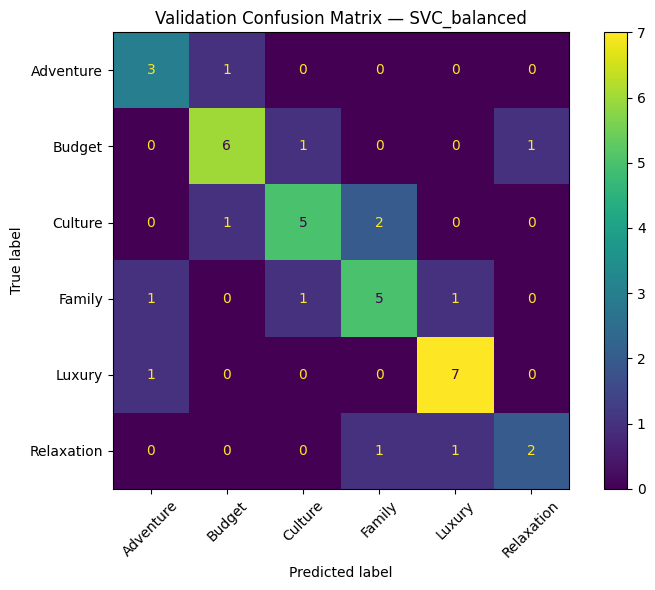

In [82]:
labels = sorted(y.unique().tolist())

for model_name, fitted in fitted_models.items():
    val_pred = fitted.predict(X_val)
    cm = confusion_matrix(y_val, val_pred, labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, values_format="d", xticks_rotation=45)
    ax.set_title(f"Validation Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

## 18. Add interpretability

Interpretability is not proof of causation. It only tells us which features the fitted model used strongly under this dataset and split.

In [ ]:
# Logistic Regression coefficients

logreg_pipe = fitted_models["LogisticRegression_balanced"]
feature_names = logreg_pipe.named_steps["preprocessor"].get_feature_names_out()
clf = logreg_pipe.named_steps["classifier"]

coef_rows = []

for class_label, coefs in zip(clf.classes_, clf.coef_, strict=False):
    top_pos_idx = np.argsort(coefs)[-10:][::-1]
    top_neg_idx = np.argsort(coefs)[:10]

    for idx in top_pos_idx:
        coef_rows.append({
            "class": class_label,
            "direction": "positive",
            "feature": feature_names[idx],
            "coefficient": coefs[idx],
        })

    for idx in top_neg_idx:
        coef_rows.append({
            "class": class_label,
            "direction": "negative",
            "feature": feature_names[idx],
            "coefficient": coefs[idx],
        })

coef_df = pd.DataFrame(coef_rows)
coef_df.to_csv(OUTPUT_DIR / "logistic_regression_top_coefficients.csv", index=False)
coef_df.head(20)

,class,direction,feature,coefficient
0,Adventure,positive,categorical__Type_Adventure,2.413480
1,Adventure,positive,categorical__Best Season_Autumn,0.718619
2,Adventure,positive,categorical__Country_Kenya,0.594522
3,Adventure,positive,categorical__Country_Argentina,0.403782
4,Adventure,positive,categorical__Country_China,0.373613
5,Adventure,positive,categorical__Continent_Europe,0.319104
6,Adventure,positive,categorical__Country_Mexico,0.240884
7,Adventure,positive,categorical__Country_Spain,0.231528
8,Adventure,positive,categorical__Continent_South America,0.195540
9,Adventure,positive,categorical__Country_Germany,0.136297


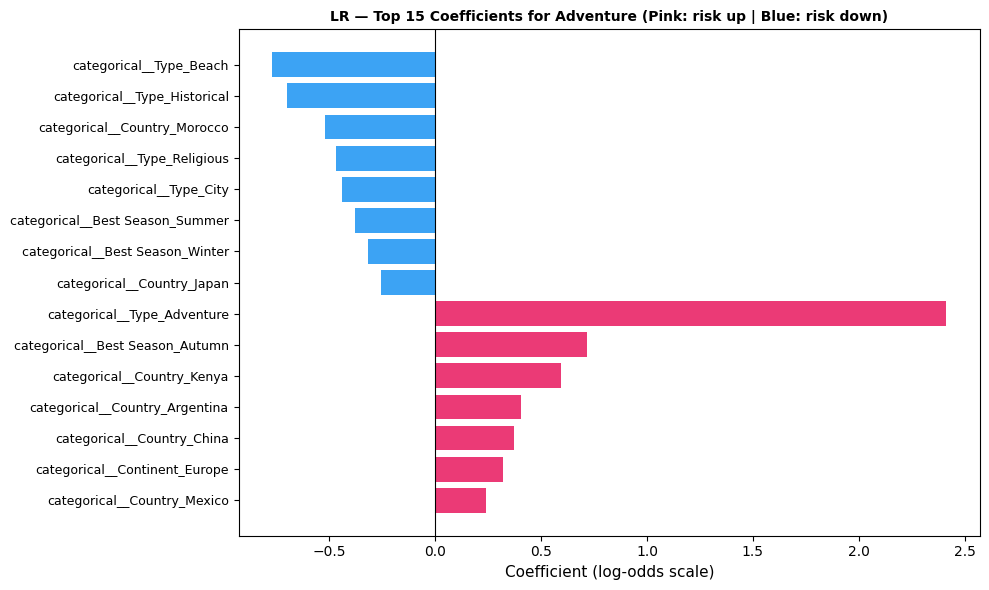

In [84]:
selected_class = 'Adventure'
filtered_coefs = coef_df[coef_df['class'] == selected_class].copy()

# Sort by absolute coefficient value to get top 15 (as suggested by the plot title)
filtered_coefs['abs_coefficient'] = filtered_coefs['coefficient'].abs()
filtered_coefs = filtered_coefs.sort_values(by='abs_coefficient', ascending=False).head(15)

top_k = len(filtered_coefs)
feat_names_lr = filtered_coefs['feature'].values
coefs_to_plot = filtered_coefs['coefficient'].values

# Reorder for plotting: positive on top, then negative
positive_coefs = filtered_coefs[filtered_coefs['coefficient'] > 0].sort_values(by='coefficient', ascending=True)
negative_coefs = filtered_coefs[filtered_coefs['coefficient'] < 0].sort_values(by='coefficient', ascending=False)

# Combine them for display
plotting_data = pd.concat([positive_coefs, negative_coefs])

feat_names_lr = plotting_data['feature'].values
coefs_to_plot = plotting_data['coefficient'].values
plot_idx = range(len(plotting_data))
top_k = len(plotting_data)

colors_coef = ['#E91E63' if c > 0 else '#2196F3' for c in coefs_to_plot]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_idx, coefs_to_plot, color=colors_coef, edgecolor='none', alpha=0.88)
ax.set_yticks(plot_idx)
ax.set_yticklabels(feat_names_lr, fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds scale)', fontsize=11)
ax.set_title(f'LR — Top {top_k} Coefficients for {selected_class} (Pink: risk up | Blue: risk down)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [85]:
# Permutation importance on validation data for the best validation model

perm = permutation_importance(
    best_validation_model,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=None,
)

perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_df.to_csv(OUTPUT_DIR / "permutation_importance_best_validation_model.csv", index=False)
perm_df

,feature,importance_mean,importance_std
2,Type,0.341287,0.129162
3,Avg Cost (USD/day),0.297242,0.058316
7,UNESCO Site,0.028086,0.016440
6,Annual Visitors (M),0.006702,0.033973
5,Avg Rating,0.000230,0.025279
1,Continent,-0.005275,0.030130
4,Best Season,-0.017086,0.023904
0,Country,-0.054539,0.024343


## 19. Threshold analysis

This step is for binary classification. Our task is multiclass, so threshold analysis is **not applicable** here.

If this were binary, we would analyse predicted probabilities and test different decision thresholds instead of relying only on 0.5.

## 20. Tuning Best Model

We tune Random Forest because it handles mixed tabular features well and supports class weighting.

Hyperparameters searched:

- `n_estimators`: number of trees
- `max_depth`: controls overfitting
- `min_samples_leaf`: regularises leaves
- `class_weight`: keeps imbalance handling active

Tuning uses training/CV data only. The test set remains untouched.

In [86]:
rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

param_grid = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [None, 8],
    "classifier__min_samples_leaf": [1, 3],
    "classifier__class_weight": ["balanced"],
}

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=None,
    refit=True,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest CV macro F1:", grid_search.best_score_)

tuning_df = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")
tuning_df.to_csv(OUTPUT_DIR / "tuning_results.csv", index=False)

tuning_df[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_classifier__n_estimators",
    "param_classifier__max_depth",
    "param_classifier__min_samples_leaf",
    "param_classifier__class_weight",
]].head(10)

Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}

Best CV macro F1: 0.7943097643097643


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf,param_classifier__class_weight
2,1,0.794310,0.095429,1.000000,100,8,1,balanced
0,2,0.745663,0.117783,1.000000,100,None,1,balanced
1,3,0.741707,0.105234,0.908828,100,None,3,balanced
3,4,0.731346,0.099834,0.906542,100,8,3,balanced


In [99]:
tuned_model = grid_search.best_estimator_
tuned_val_pred = tuned_model.predict(X_val)

tuned_result = {
    "model": "RandomForest_tuned",
    "train_accuracy": accuracy_score(y_train, tuned_model.predict(X_train)),
    "train_macro_f1": f1_score(y_train, tuned_model.predict(X_train), average="macro", zero_division=0),
    "val_accuracy": accuracy_score(y_val, tuned_val_pred),
    "val_macro_f1": f1_score(y_val, tuned_val_pred, average="macro", zero_division=0),
    "val_precision_macro": precision_score(y_val, tuned_val_pred, average="macro", zero_division=0),
    "val_recall_macro": recall_score(y_val, tuned_val_pred, average="macro", zero_division=0),
}
tuned_result["train_val_accuracy_gap"] = tuned_result["train_accuracy"] - tuned_result["val_accuracy"]
tuned_result["train_val_macro_f1_gap"] = tuned_result["train_macro_f1"] - tuned_result["val_macro_f1"]

all_results_df = pd.concat([results_df, pd.DataFrame([tuned_result])], ignore_index=True)
all_results_df = all_results_df.sort_values("val_macro_f1", ascending=False)
all_results_df.to_csv(OUTPUT_DIR / "results.csv", index=False)

all_results_df

,model,train_accuracy,train_macro_f1,val_accuracy,val_macro_f1,val_precision_macro,val_recall_macro,train_val_accuracy_gap,train_val_macro_f1_gap
4,RandomForest_tuned,1.000000,1.000000,0.850,0.850482,0.850265,0.875000,0.150000,0.149518
0,RandomForest_balanced,1.000000,1.000000,0.800,0.793838,0.798413,0.812500,0.200000,0.206162
1,LogisticRegression_balanced,0.983333,0.983121,0.675,0.673795,0.693849,0.708333,0.308333,0.309325
2,ExtraTrees_balanced,1.000000,1.000000,0.625,0.646083,0.663853,0.666667,0.375000,0.353917
3,HistGradientBoosting_balanced,1.000000,1.000000,0.550,0.525482,0.524074,0.541667,0.450000,0.474518


## 21. Select the final model

We choose based on validation/CV behaviour, with macro F1 as the main metric.

In [88]:
selected_model_name = all_results_df.iloc[0]["model"]
print("Selected model:", selected_model_name)

if selected_model_name == "RandomForest_tuned":
    selected_pipeline = clone(tuned_model)
else:
    selected_pipeline = clone(models[selected_model_name])

print("Selection reason: highest validation macro F1 among untuned and tuned candidates, while test set remains untouched.")

Selected model: RandomForest_tuned
Selection reason: highest validation macro F1 among untuned and tuned candidates, while test set remains untouched.


## 22. Final evaluation on untouched test set

Now we refit the selected model on train + validation, then evaluate once on the test set.

In [89]:
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

final_pipeline = clone(selected_pipeline)
final_pipeline.fit(X_train_val, y_train_val)

test_pred = final_pipeline.predict(X_test)

final_metrics = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "selected_model": selected_model_name,
    "test_accuracy": accuracy_score(y_test, test_pred),
    "test_macro_f1": f1_score(y_test, test_pred, average="macro", zero_division=0),
    "test_precision_macro": precision_score(y_test, test_pred, average="macro", zero_division=0),
    "test_recall_macro": recall_score(y_test, test_pred, average="macro", zero_division=0),
}

final_metrics

{'timestamp': '2026-04-28T20:29:19',
 'selected_model': 'RandomForest_tuned',
 'test_accuracy': 0.65,
 'test_macro_f1': 0.6242424242424243,
 'test_precision_macro': 0.673611111111111,
 'test_recall_macro': 0.6574074074074074}

In [90]:
print("Final classification report:")
print(classification_report(y_test, test_pred, zero_division=0))

report_df = pd.DataFrame(classification_report(y_test, test_pred, output_dict=True, zero_division=0)).transpose()
report_df.to_csv(OUTPUT_DIR / "final_classification_report.csv")
report_df

Final classification report:
              precision    recall  f1-score   support

   Adventure       0.62      1.00      0.77         5
      Budget       0.75      0.43      0.55         7
     Culture       0.67      1.00      0.80         8
      Family       1.00      0.44      0.62         9
      Luxury       0.67      0.57      0.62         7
  Relaxation       0.33      0.50      0.40         4

    accuracy                           0.65        40
   macro avg       0.67      0.66      0.62        40
weighted avg       0.72      0.65      0.64        40



,precision,recall,f1-score,support
Adventure,0.625000,1.000000,0.769231,5.00
Budget,0.750000,0.428571,0.545455,7.00
Culture,0.666667,1.000000,0.800000,8.00
Family,1.000000,0.444444,0.615385,9.00
Luxury,0.666667,0.571429,0.615385,7.00
Relaxation,0.333333,0.500000,0.400000,4.00
accuracy,0.650000,0.650000,0.650000,0.65
macro avg,0.673611,0.657407,0.624242,40.00
weighted avg,0.717708,0.650000,0.637762,40.00


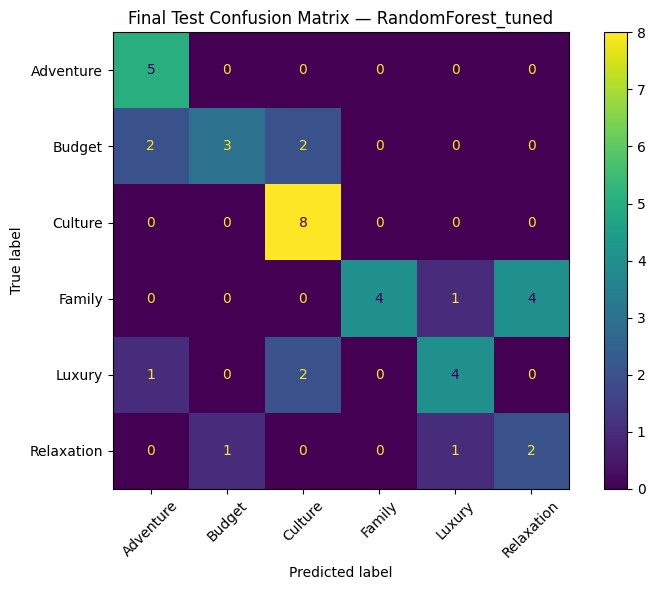

,Adventure,Budget,Culture,Family,Luxury,Relaxation
Adventure,5,0,0,0,0,0
Budget,2,3,2,0,0,0
Culture,0,0,8,0,0,0
Family,0,0,0,4,1,4
Luxury,1,0,2,0,4,0
Relaxation,0,1,0,0,1,2


In [91]:
final_cm = confusion_matrix(y_test, test_pred, labels=labels)
final_cm_df = pd.DataFrame(final_cm, index=labels, columns=labels)
final_cm_df.to_csv(OUTPUT_DIR / "final_confusion_matrix.csv")

disp = ConfusionMatrixDisplay(confusion_matrix=final_cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, values_format="d", xticks_rotation=45)
ax.set_title(f"Final Test Confusion Matrix — {selected_model_name}")
plt.tight_layout()
plt.show()

final_cm_df

## 23. Save outputs

We save:

- final fitted sklearn pipeline with joblib
- model comparison results
- CV results
- tuning results
- final test metrics
- classification report
- confusion matrix
- feature metadata

In [92]:
model_path = MODEL_DIR / "final_travel_style_pipeline.joblib"
joblib.dump(final_pipeline, model_path)

with open(OUTPUT_DIR / "final_test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=2)

metadata = {
    "dataset_path": str(DATASET_PATH),
    "target_column": TARGET_COLUMN,
    "problem_type": "multiclass classification",
    "random_state": RANDOM_STATE,
    "id_columns_removed": ID_COLUMNS,
    "leakage_columns_removed": LEAKAGE_COLUMNS,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "classes": labels,
    "class_distribution_full": y.value_counts().to_dict(),
    "selected_model": selected_model_name,
    "model_path": str(model_path),
    "primary_metric": "macro F1",
    "note": "Destination Name excluded to reduce memorisation. Test set evaluated only once after model selection.",
}

with open(OUTPUT_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved model to:", model_path)
print("Saved outputs to:", OUTPUT_DIR)

Saved model to: ../models/final_travel_style_pipeline.joblib
Saved outputs to: ../outputs


## Final notes for the README

Use this wording in your explanation:

- I used a stratified split because the target classes are not perfectly balanced.
- I used macro F1 as the main metric because every class should matter equally.
- I excluded `Destination Name` to reduce memorisation.
- I kept preprocessing inside the sklearn pipeline to avoid data leakage.
- I used class weighting instead of oversampling because this workflow stays within sklearn.
- I evaluated the final selected model once on the untouched test set.